# Simulating Balatro: A Python-Based Monte Carlo Analysis for Better Game Development


In [1]:
import numpy as np
import random
import itertools
from collections import Counter, defaultdict
from scipy import stats
import matplotlib.pyplot as plt

### Target Scores


#### First 3 Antes and Their Target Scores

| **First 3 Antes** | **Blind**             | **Target Score** |
|-------------------|------------------------|------------------|
| **Ante 1**        | 1 (Small Blind)        | 300              |
|                   | 2 (Big Blind)          | 450              |
|                   | 3 (Boss Blind)         | 600              |
| **Ante 2**        | 4 (Small Blind)        | 800              |
|                   | 5 (Big Blind)          | 1000             |
|                   | 6 (Boss Blind)         | 1200             |
| **Ante 3**        | 7 (Small Blind)        | 1600             |
|                   | 8 (Big Blind)          | 1900             |
|                   | 9 (Boss Blind)         | 2200             |


In [2]:
# Create function to generate schdule of test scores (default is 100 antes if not specified)
def generate_target_scores(num_antes=100):
    targets = []
    for a in range(1, num_antes+1):
        base = 300 + 500 * (a-1)
        for b in range(1,4): 
            target = base + 150 * (b-1)
            targets.append({"ante": a, "blind": b, "target_score": target})
    return targets

### Deck and Card Class

In [3]:
card_rank = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']
card_suit = ['Hearts', 'Diamonds', 'Clubs', 'Spades']

# create card class to construct deck
class card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
    def __repr__(self):
        return f"{self.rank} of {self.suit}"


# create deck class to manage deck shuffling and drawing
class Deck:
    def __init__(self):
        self.cards = [card(rank, suit) for rank in card_rank for suit in card_suit]

    def shuffle(self):
        random.shuffle(self.cards)

    def draw(self, n=8):
        drawn_cards = self.cards[ :n]
        self.cards = self.cards[n: ]
        return drawn_cards

#     def reset(self):
#         self.__init__()
#         self.shuffle()

### Base Hand Values

In [4]:
# Define rank for each card for detecting patterns for played hands
RANK_ORDER = {'2': 2, '3': 3, '4': 4, '5': 5, '6': 6,'7': 7, '8': 8, '9': 9, '10': 10,'J': 11, 'Q': 12, 'K': 13, 'A': 14}

# Base scoring formula before any planets and jokers
# For ex, Pair gives 10 chips x 2 mult = 20 base score 
HAND_VALUES = {
    "Straight Flush": (100, 8),
    "Four of a Kind": (60, 7),
    "Full House": (40, 4),
    "Flush": (35, 4),
    "Straight": (30, 4),
    "Three of a Kind": (30, 3),
    "Two Pair": (20, 2),
    "Pair": (10, 2),
    "High Card": (5, 1)
}

# Turn chips/mult tuple to list in order to update scoring with planet and joker multipliers 
def hand_values_chart_init():
    return {key: list(val) for key, val in HAND_VALUES.items()}       


### Evaluation of Hands Logic

In [5]:
# Create function evaluate_hand to determine the best playable hand
def evaluate_hand(cards, hand_values):

    ranks = [RANK_ORDER[each.rank] for each in cards] # covert card ranks to numerical values
    suits = [each.suit for each in cards] # store suits
    
    # Count duplicates and sort from largest to smallest to detect pairs/triples/4 of a kind
    rank_counts = Counter(ranks)
    counts = sorted(rank_counts.values(), reverse=True)
    
    # check if hand is a flush
    flush_hand = len(set(suits)) == 1

    # check for a straight 
    sorted_ranks = sorted(set(ranks))
    a2345 = sorted_ranks == [2, 3, 4, 5, 14] # also count A,2,3,4,5 as a straight
    straight_hand = (
        len(sorted_ranks) == 5 and
        (max(sorted_ranks) - min(sorted_ranks) == 4 or a2345)
    )

    if straight_hand and flush_hand:
        name = "Straight Flush"
    elif counts == [4, 1]:
        name = "Four of a Kind"
    elif counts == [3, 2]:
        name = "Full House"
    elif flush_hand:
        name = "Flush"
    elif straight_hand:
        name = "Straight"
    elif counts == [3,1,1]:
        name = "Three of a Kind"
    elif counts == [2,2,1]:
        name = "Two Pair"
    elif counts == [2,1,1,1]:
        name = "Pair"
    else:
        name = "High Card"

    # Use HAND_VALUES mapping later on to obtain chips and mult for each hand
    chips, mult = hand_values[name] 
    return name, chips, mult


def face_value(cards):
    values = {'J': 10, 'Q': 10, 'K': 10, 'A': 11}
    total = 0
    for c in cards:
        total += int(c.rank) if c.rank.isdigit() else values[c.rank]
    return total

def hand_score(cards, hand_values):
    name, chips, mult = evaluate_hand(cards,hand_values)
    score = chips*mult + face_value(cards)
    return score, name, chips, mult

# Out of the 8 cards, determine the best pokerhand. 
def best_five_of_eight(dealt_cards, hand_values):
    
    optimal_combo, optimal_score, optimal_details = None, -1, None
    for each in itertools.combinations(dealt_cards,5):
        score, name, chips, mult = hand_score(each,hand_values)
        if score > optimal_score:
            optimal_combo, optimal_score, optimal_details = each, score, (name, chips, mult)

    optimal_hand_type = optimal_details[0]

    # Replace kickers with low-value cards for hands that don't require all 5 cards to score
    if optimal_hand_type in ["Pair", "Two Pair", "Three of a Kind", "Four of a Kind"]:
        ranks = [x.rank for x in dealt_cards]
        rank_counts = Counter(ranks)
        key_ranks = [r for r, count in rank_counts.items() if count > 1]
        
        # Define main cards and kickers
        main_cards = [c for c in dealt_cards if c.rank in key_ranks]
        kickers = sorted(
            [c for c in dealt_cards if c not in main_cards],
            key=lambda x: RANK_ORDER[x.rank]
        )
        
        # Combine main cards and kickers for full hand
        chosen = main_cards + kickers[:5 - len(main_cards)]
        return chosen, optimal_score, optimal_details

    return optimal_combo, optimal_score, optimal_details

### Jokers Cards

<table align="left">
  <tr>
    <th>Joker Name</th>
    <th>Effect</th>
    <th>Activation Condition</th>
  </tr>
  <tr>
    <td>Joker</td>
    <td>+4 Mult</td>
    <td>Always active</td>
  </tr>
  <tr>
    <td>Jolly Joker</td>
    <td>+8 Mult</td>
    <td>When the hand type is Pair</td>
  </tr>
  <tr>
    <td>Devious Joker</td>
    <td>+100 Chips</td>
    <td>When the hand type is Straight</td>
  </tr>
  <tr>
    <td>Scholar</td>
    <td>+20 Chips, +4 Mult</td>
    <td>When the hand contains at least one Ace</td>
  </tr>
  <tr>
    <td>Even Steven</td>
    <td>+4 Mult</td>
    <td>When all numeric cards are even (2, 4, 6, 8, 10)</td>
  </tr>
  <tr>
    <td>Odd Todd</td>
    <td>+31 Chips</td>
    <td>When all cards are odd (A, 3, 5, 7, 9)</td>
  </tr>
  <tr>
    <td>Smiley Face</td>
    <td>+5 Mult</td>
    <td>When the hand contains any face card (J, Q, K)</td>
  </tr>
  <tr>
    <td>Shoot the Moon</td>
    <td>+13 Mult</td>
    <td>When the hand contains at least one Queen</td>
  </tr>
  <tr>
    <td>Mad Joker</td>
    <td>+10 Mult</td>
    <td>When hand contains 2 pairs</td>
  </tr>
  <tr>
    <td>Abstract Joker</td>
    <td>+3 Mult per Joker owned</td>
    <td>Always active; scales with number of Jokers</td>
  </tr>
</table>



In [6]:
# Create dict to store joker effects
# Jokers are all either a mult bonus, a chip_bonus, or its Abstract Joker which is +3 mult per active joker
JOKERS = [
    {"name": "Joker", "mult_bonus": 4, "condition": lambda x: True},
    {"name": "Jolly Joker", "mult_bonus": 8, "condition": lambda x: evaluate_hand(x, HAND_VALUES)[0] == "Pair"},
    {"name": "Devious Joker", "chips_bonus": 100, "condition": lambda x: evaluate_hand(x, HAND_VALUES)[0] == "Straight"},
    {"name": "Scholar", "chips_bonus": 20, "mult_bonus": 4, "condition": lambda x: any(y.rank == 'A' for y in x)},
    {"name": "Even Steven", "mult_bonus": 4, "condition": lambda x: all(int(y.rank) % 2==0 for y in x if y.rank.isdigit())},
    {"name": "Odd Todd","chips_bonus": 31, "condition": lambda x: all(y.rank in ['A','3','5','7','9'] for y in x)},
    {"name": "Smiley Face", "mult_bonus": 5, "condition": lambda x: any(y.rank in ['J','Q','K'] for y in x)},
    {"name": "Shoot the Moon", "mult_bonus": 13, "condition": lambda x: any(y.rank == 'Q' for y in x)},
    {"name": "Mad Joker", "mult_bonus": 10, "condition": lambda x: evaluate_hand(x, HAND_VALUES)[0] == "Two Pair"},
    {"name": "Abstract Joker", "mult_per_joker": 3}
]

# define function apply_jokers to loop through active jokers, check current hand if joker should apply, 
#if so then return the boosted chips/mult
def apply_jokers(cards, chips, mult, jokers):
    for each in jokers:
        cond = each.get("condition", lambda x: True)
        
        # Depending on current hand, apply either mult or chips bonus. 
        # Except abstract joker which gives +3 mult per active joker
        if cond(cards):
            if "chips_bonus" in each:
                chips += each["chips_bonus"]
            if "mult_bonus" in each:
                mult += each["mult_bonus"]
            if "mult_per_joker" in each:
                mult += each["mult_per_joker"] * len(jokers)
    return chips, mult

### Planet Cards

<table align="left">
  <tr>
    <th>Planet card</th>
    <th>Poker Hand</th>
    <th>Addition</th>
  </tr>

  <tr>
    <td>Pluto</td>
    <td>High Card</td>
    <td>+1 Mult and +10 Chips</td>
  </tr>

  <tr>
    <td>Mercury</td>
    <td>Pair</td>
    <td>+1 Mult and +15 Chips</td>
  </tr>

  <tr>
    <td>Uranus</td>
    <td>Two Pair</td>
    <td>+1 Mult and +20 Chips</td>
  </tr>

  <tr>
    <td>Venus</td>
    <td>Three of a Kind</td>
    <td>+2 Mult and +20 Chips</td>
  </tr>

  <tr>
    <td>Saturn</td>
    <td>Straight</td>
    <td>+3 Mult and +30 Chips</td>
  </tr>

  <tr>
    <td>Jupiter</td>
    <td>Flush</td>
    <td>+2 Mult and +15 Chips</td>
  </tr>

  <tr>
    <td>Earth</td>
    <td>Full House</td>
    <td>+2 Mult and +25 Chips</td>
  </tr>

  <tr>
    <td>Mars</td>
    <td>Four of a Kind</td>
    <td>+3 Mult and +30 Chips</td>
  </tr>

  <tr>
    <td>Neptune</td>
    <td>Straight Flush</td>
    <td>+4 Mult and +40 Chips</td>
  </tr>
</table>


In [7]:
# Create dict to store planet card effects
planetcards = {
    "Pluto": {"hand": "High Card", "mult_bonus": 1, "chips_bonus": 10},
    "Mercury": {"hand": "Pair", "mult_bonus": 1, "chips_bonus": 15},
    "Uranus": {"hand": "Two Pair", "mult_bonus": 1, "chips_bonus": 20},
    "Venus": {"hand": "Three of a Kind", "mult_bonus": 2, "chips_bonus": 20},
    "Saturn": {"hand": "Straight", "mult_bonus": 3, "chips_bonus": 30},
    "Jupiter": {"hand": "Flush", "mult_bonus": 2, "chips_bonus": 15},
    "Earth": {"hand": "Full House", "mult_bonus": 2, "chips_bonus": 25},
    "Mars": {"hand": "Four of a Kind", "mult_bonus": 3, "chips_bonus": 30},
    "Neptune": {"hand": "Straight Flush", "mult_bonus": 4, "chips_bonus": 40},
}

# Based on dict above, define a function to apply planet card to mult and chip scoring
def apply_planet(hand_values, earned_planets):
    # check to see what planets have not been applied yet
    available = [x for x in planetcards.keys() if x not in earned_planets] 
    if not available:
        return hand_values, earned_planets

    planet = random.choice(available) #Pick a random card from available planets
    
    # From dict, extract the target hand, bonus mult and bonus chips
    target = planetcards[planet]["hand"]
    bonus_mult = planetcards[planet]["mult_bonus"]
    bonus_chips = planetcards[planet]["chips_bonus"]

    # Apply the effect
    hand_values[target][0] += bonus_chips
    hand_values[target][1] += bonus_mult
    
    # Record which planets are earned
    earned_planets.add(planet)

    return hand_values, earned_planets

### Simulation Loop

In [8]:
def lets_go_balatro(num_antes=5, verbose=True):

    # Call generate_target_scores function to build schedule of target scores
    targets = generate_target_scores(num_antes)
    
    # Initialize state
    active_jokers = [] # list of currently active jokers
    earned_planets = set() # which planets are currently active
    total_score = 0 # Cumaltive score across all rounds
    blinds_clearned = 0 # How many rounds (blinds) have been cleared
    hand_values = hand_values_chart_init() # initialize scoring chart
    hand_history = Counter() # NEW: track all poker hands obtained during the game
    joker_history = Counter() # NEW: track all jokers obtained during the game
    planet_history = Counter() # NEW: track all planets obtained during the game
    

    # Loop through each blind and ante and obtain target score as per schedule
    for each in targets:
        ante = each["ante"]
        blind = each["blind"]
        target_score = each["target_score"]

        # At the start of each new ante, print the ante number and which planets/jokers are active
        if blind == 1 and verbose:
            print(f"\n \/\/\/\/\ Starting Ante {ante} /\/\/\/\/")
            print("Active Jokers:", [x["name"] for x in active_jokers] or ["None"])
            print("Active Planets:", list(earned_planets) or ["None"])

        # For each new blind, start a new deck, active shuffle method, and use draw method to obtain top 8 cards from deck
        deck = Deck()
        deck.shuffle()
        hand = deck.draw(8)

        if verbose:
            print(f"\nAnte {ante}, Blind {blind}, Target: {target_score}")

        blind_cleared = False
        hands_played = 0
        blind_total = 0
        new_jokers, new_planets = [],[]

        # Each blind has a max of 5 playable hands
        while hands_played < 5:
            
            # Refill to 8 cards if short
            if len(hand) < 8:
                # If the number of cards in deck reaches zero then game over
                if len(deck.cards) == 0:
                    if verbose:
                        print("Deck exhausted. GAME OVER.")
                        
                    antes_cleared = blinds_clearned // 3
                    return antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history
                hand += deck.draw(min(8 - len(hand), len(deck.cards))) 

            # Evaluate best 5-card poker hand using best_five_of_eight function
            best_combo, best_score, details = best_five_of_eight(hand, hand_values)
            hand_type, chips, mult = details

            # NEW: Track what type of poker hand was obtained
            hand_history[hand_type] += 1

            # If best poker hand is High Card, then player can redraw once
            performed_discard = False
            if hand_type == "High Card" and not performed_discard:
                if len(deck.cards) < 8:
                    if verbose:
                        print("Not enough cards to redraw. GAME OVER.")
                    
                    antes_cleared = blinds_clearned // 3
                    return antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history
                hand = deck.draw(8)
                performed_discard = True
                best_combo, best_score, details = best_five_of_eight(hand,hand_values)
                hand_type, chips, mult = details
                hand_history[hand_type] += 1 # NEW: track hand again after redraw

            # If best poker hand is Pair, then player can redraw once
            elif hand_type == "Pair" and not performed_discard:
                pair_ranks = [x.rank for x in best_combo]
                rank_counts = Counter(pair_ranks)
                pair_rank = [x for x, count in rank_counts.items() if count == 2][0]
                hand = [x for x in hand if x.rank == pair_rank]
                how_many_cards = 8 - len(hand)
                if len(deck.cards) < how_many_cards:
                    if verbose:
                        print("Not enough cards to redraw. GAME OVER.")
                    antes_cleared = blinds_clearned // 3
                    return antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history
                hand += deck.draw(how_many_cards)
                performed_discard = True
                best_combo, best_score, details = best_five_of_eight(hand, hand_values)
                hand_type, chips, mult = details
                hand_history[hand_type] += 1 # NEW: track hand again after redraw

            # Apply the joker effects and compute round score and total cumulative score
            chips, mult = apply_jokers(best_combo, chips, mult, active_jokers)
            final_score = chips * mult + face_value(best_combo)
            total_score += final_score
            blind_total += final_score
            hands_played += 1
            
            # For each play, print full details in the output
            if verbose:
                print(f"Play {hands_played}: {hand_type} | Chips: {chips}, Mult: {mult}, "
                      f"Score: {final_score} | Running Total: {blind_total} | "
                      f"Cards left in deck: {len(deck.cards)} | Redraw: {'Yes' if performed_discard else 'No'}")

            # Check if player reached target, if so then print score of cleared blind and how many plays it took
            # Additionally, player has chance to obtain a new joker and planet card
            if blind_total >= target_score:
                blind_cleared = True
                blinds_clearned += 1
                if verbose:
                    print(f"Cleared target {target_score} with cumulative score "
                          f"{blind_total} in {hands_played} plays.")

                # 50/50 chance to get one of the planet cards each blind, up to a max of 5 total
                if len(active_jokers) < 5 and random.random() < 0.5:
                    available = [x for x in JOKERS if x not in active_jokers]
                    if available:
                        new_joker = random.choice(available)
                        active_jokers.append(new_joker)
                        new_jokers.append(new_joker["name"]) # track newly obtained joker
                        joker_history[new_joker["name"]] += 1 # NEW: track joker occurrence

                # 50/50 chance to get one of the planet cards each blind, up to a max of 4 total
                if len(earned_planets) < 4 and random.random() < 0.5:
                    old_planets = set(earned_planets)
                    hand_values, earned_planets = apply_planet(hand_values, earned_planets)
                    new_planets = list(earned_planets-old_planets) # track newly obtained planet
                    for p in new_planets:
                        planet_history[p] += 1 # NEW: track planet occurrence

                # Indicate any new joker or planet cards onbtained after each blind
                if verbose:
                    for each in new_jokers:
                        print(f"New Joker obtained: {each}")
                    for each in new_planets:
                        print(f"New Planet obtained: {each}")

                break  # Stop game here as player has reached target

            # If player failed to reach target and clear blind after play, 
            # then discard played cards and continue to next play
            for each in best_combo:
                if each in hand:
                    hand.remove(each)
            
            # Refill back to 8 cards total. 
            # If unsufficient number of cards in deck, then game over
            how_many_cards = 8-len(hand) 
            if len(deck.cards) >= how_many_cards:
                hand += deck.draw(how_many_cards)
            else:
                if verbose:
                    print("Deck exhausted. GAME OVER.")
                
                antes_cleared = blinds_clearned // 3
                return antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history

        # If player has not reached target after all 5 plays, then game over.
        if not blind_cleared:
            if verbose:
                print(f"Failed to reach {target_score} after five plays "
                      f"(Total accumulated: {blind_total}).")
            break

    antes_cleared = blinds_clearned // 3
    return antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history


### Run one game of Balatro and print details of each blind

In [9]:
antes_cleared, blinds_clearned, total_score, hand_values, hand_history, joker_history, planet_history = lets_go_balatro(num_antes=100)
print(f"\nAntes Cleared: {antes_cleared}, Blinds Cleared: {blinds_clearned}, Total Score: {total_score}\n")


 \/\/\/\/\ Starting Ante 1 /\/\/\/\/
Active Jokers: ['None']
Active Planets: ['None']

Ante 1, Blind 1, Target: 300
Play 1: Straight | Chips: 30, Mult: 4, Score: 167 | Running Total: 167 | Cards left in deck: 44 | Redraw: No
Play 2: Two Pair | Chips: 20, Mult: 2, Score: 73 | Running Total: 240 | Cards left in deck: 39 | Redraw: No
Play 3: Full House | Chips: 40, Mult: 4, Score: 188 | Running Total: 428 | Cards left in deck: 34 | Redraw: No
Cleared target 300 with cumulative score 428 in 3 plays.
New Planet obtained: Earth

Ante 1, Blind 2, Target: 450
Play 1: Pair | Chips: 10, Mult: 2, Score: 45 | Running Total: 45 | Cards left in deck: 38 | Redraw: Yes
Play 2: Two Pair | Chips: 20, Mult: 2, Score: 76 | Running Total: 121 | Cards left in deck: 33 | Redraw: No
Play 3: Three of a Kind | Chips: 30, Mult: 3, Score: 127 | Running Total: 248 | Cards left in deck: 28 | Redraw: No
Play 4: Straight | Chips: 30, Mult: 4, Score: 164 | Running Total: 412 | Cards left in deck: 17 | Redraw: Yes
Pla

### Run 10,000 simulations of Balatro

In [10]:
# Run 1000 simulations silently and store results in list of tuples
num_sims = 1000
results = [lets_go_balatro(num_antes=100, verbose=False) for _ in range(num_sims)]

# Unpack stats for report summary report
antes_results = [x[0] for x in results] # Total number of antes cleared in each run
blinds_results = [x[1] for x in results] # Total number of blinds (rounds) cleared in each run
scores = [x[2] for x in results] # Final cumulative score at the end of each run
hand_value_dicts = [x[3] for x in results] # Dict of final chips/mult for each poker hand after the run
hand_hist = [x[4] for x in results] # Count how many times each poker hand appeared during the run
joker_hist = [x[5] for x in results] # Count of all Jokers obtained during the run
planet_hist = [x[6] for x in results] # Count of all Planets obtained during the run

### Summary Reports

### Distribution of Blinds Cleared Across 1,000 Simulations

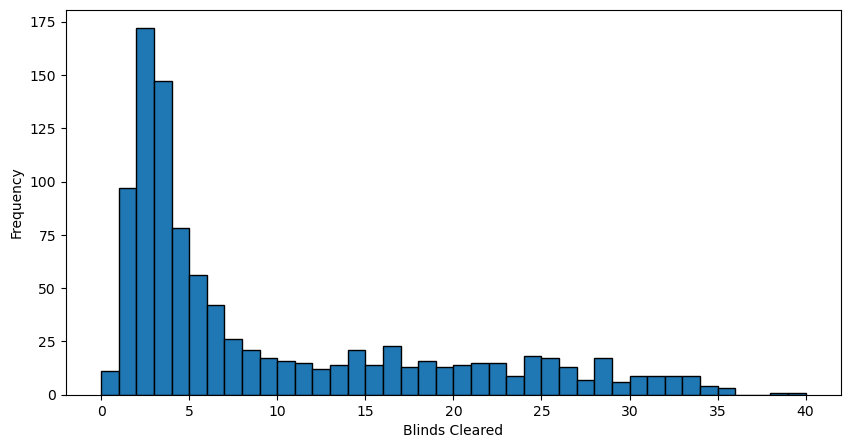

In [11]:
# Show distribution of blinds cleared
plt.figure(figsize=(10,5))
plt.hist(blinds_results, bins=range(min(blinds_results), max(blinds_results) + 2), edgecolor='black')
plt.xlabel("Blinds Cleared")
plt.ylabel("Frequency")
plt.show()

### Mean and 95% Confidence Intervals for antes cleared, blinds cleared, and scores obtained 

In [12]:
# Convert lists to arrays for numerical work
antes_arr = np.array(antes_results)
blinds_arr = np.array(blinds_results)
scores_arr = np.array(scores)

# Compute mean and 95% CI for antes cleared, blinds cleared, and scores obtained 
# Antes
antes_mean = np.mean(antes_arr) # get mean
antes_standard_error = stats.sem(antes_arr) # get standard error
antes_margin = antes_standard_error * stats.t.ppf(0.975, len(antes_arr) - 1) # get margin. 97.5% to capture the 2.5% at each tail
antes_low = antes_mean - antes_margin # lower bound
antes_high = antes_mean + antes_margin # upper bound

# Blinds
blinds_mean = np.mean(blinds_arr)
blinds_standard_error = stats.sem(blinds_arr)
blinds_margin = blinds_standard_error * stats.t.ppf(0.975, len(blinds_arr) - 1)
blinds_low = blinds_mean - blinds_margin
blinds_high = blinds_mean + blinds_margin

# Scores
scores_mean = np.mean(scores_arr)
scores_standard_error = stats.sem(scores_arr)
scores_margin = scores_standard_error * stats.t.ppf(0.975, len(scores_arr) - 1)
scores_low = scores_mean - scores_margin
scores_high = scores_mean + scores_margin


print(f"Antes Cleared: Mean={antes_mean:.2f}, 95% Condifidence Interval=({antes_low:.4f}, {antes_high:.4f})")
print(f"Blinds Cleared: Mean={blinds_mean:.2f}, 95% Condifidence Interval=({blinds_low:.4f}, {blinds_high:.2f})")
print(f"Scored Obtained: Mean={scores_mean:.2f}, 95% Condifidence Interval=({scores_low:.4f}, {scores_high:.4f})")

Antes Cleared: Mean=2.70, 95% Condifidence Interval=(2.5036, 2.8904)
Blinds Cleared: Mean=9.13, 95% Condifidence Interval=(8.5509, 9.70)
Scored Obtained: Mean=22185.19, 95% Condifidence Interval=(20094.9757, 24275.4023)


### Average Final Chips and Multipliers per Hand Type

In [13]:
#Create dict to collect all chip/mult values
avg_chips = defaultdict(list)
avg_mult = defaultdict(list)

# Loop through each of the sim's final hand_values
for each in hand_value_dicts:
    for hand, (chips, mult) in each.items():
        avg_chips[hand].append(chips)
        avg_mult[hand].append(mult)

# For each poker hand type, compute the average chips and average mult
avg_hand_values = {x:(sum(avg_chips[x])/len(avg_chips[x]), sum(avg_mult[x])/len(avg_mult[x])) for x in avg_chips}


for hand, (chips, mult) in avg_hand_values.items():
    print(f"{hand}, Chips: {chips}, Mult: {mult}")

Straight Flush, Chips: 110.32, Mult: 9.032
Four of a Kind, Chips: 67.35, Mult: 7.735
Full House, Chips: 46.9, Mult: 4.552
Flush, Chips: 38.885, Mult: 4.518
Straight, Chips: 37.41, Mult: 4.741
Three of a Kind, Chips: 34.92, Mult: 3.492
Two Pair, Chips: 25.14, Mult: 2.257
Pair, Chips: 13.825, Mult: 2.255
High Card, Chips: 7.75, Mult: 1.275


### Frequency of each Poker Hand across all Simulations

Pair, Count: 14439, Percentage: 29.516742303446584
Two Pair, Count: 14406, Percentage: 29.44928247270943
High Card, Count: 5209, Percentage: 10.648432069994685
Straight, Count: 4304, Percentage: 8.798397317960669
Three of a Kind, Count: 3984, Percentage: 8.144241383539802
Full House, Count: 3197, Percentage: 6.53542663232348
Flush, Count: 3026, Percentage: 6.185862054867329
Four of a Kind, Count: 300, Percentage: 0.6132711885195633
Straight Flush, Count: 53, Percentage: 0.10834457663845619


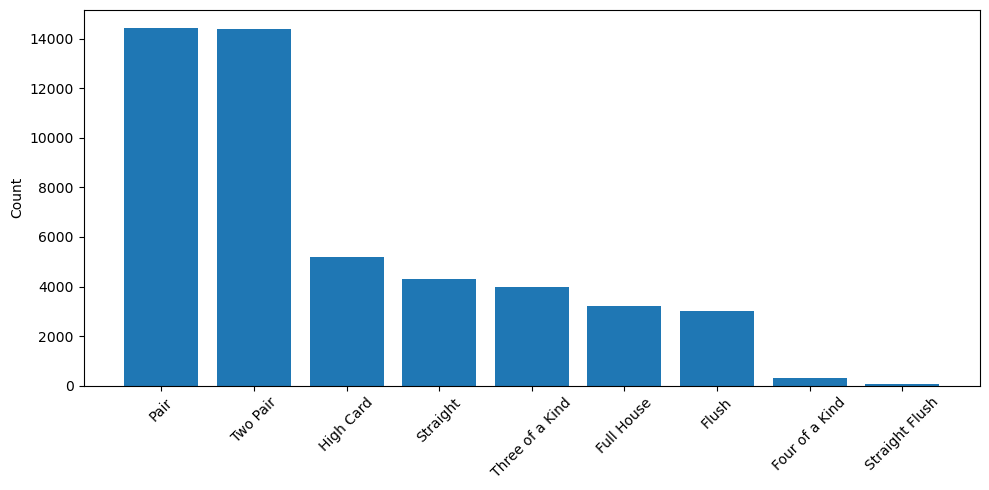

In [14]:
# Combine hand histories from all runs
combined_hands = Counter()
for each in results:
    hand_hist = each[4]
    combined_hands.update(hand_hist)

# Total hands played across all runs
total_hands = sum(combined_hands.values())

# Dict comprehension to compute percentages per hand
hand_frequency = {x: (y, 100 * y / total_hands) for x, y in combined_hands.most_common()}

# Print summary
for hand, (count, pct) in hand_frequency.items():
    print(f"{hand}, Count: {count}, Percentage: {pct}")


plt.figure(figsize=(10, 5))
plt.bar(hand_frequency.keys(), [x[0] for x in hand_frequency.values()])
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
